In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import torch
warnings.filterwarnings('ignore')

### Fault Detection in Power System Transmission Lines


1. Overview
-- Objective:  Enhance fault detection and classification in transmission lines using deep learning models.

-- Dataset: Dataset includes features such as current and voltage readings, and fault indicators.

2. Data Description
    -- Data source: https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification 
    -- Data Columns: G, C, B, A, Ia, Ib, Ic, Va, Vb, Vc
    -- Details: Explanation of the power system model and fault types.

### Loading Data

In [2]:
df = pd.read_csv('classData.csv')
df.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 non-null   float64
 6   Ic      7861 non-null   float64
 7   Va      7861 non-null   float64
 8   Vb      7861 non-null   float64
 9   Vc      7861 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 614.3 KB


In [4]:
df.describe()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
count,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000
mean,0.432006,0.411271,0.555527,0.571429,13.721194,-44.845268,34.392394,-0.007667,0.001152,0.006515
std,0.495387,0.492095,0.496939,0.494903,464.741671,439.269195,371.107412,0.289150,0.313437,0.307897
min,0.000000,0.000000,0.000000,0.000000,-883.542316,-900.526951,-883.357762,-0.620748,-0.608016,-0.612709
25%,0.000000,0.000000,0.000000,0.000000,-119.802518,-271.845947,-61.034219,-0.130287,-0.159507,-0.215977
50%,0.000000,0.000000,1.000000,1.000000,2.042805,5.513317,-4.326711,-0.005290,0.001620,0.009281
75%,1.000000,1.000000,1.000000,1.000000,227.246377,91.194282,49.115141,0.111627,0.153507,0.239973
max,1.000000,1.000000,1.000000,1.000000,885.738571,889.868884,901.274261,0.595342,0.627875,0.600179


In [5]:
df.isna().sum()

G     0
C     0
B     0
A     0
Ia    0
Ib    0
Ic    0
Va    0
Vb    0
Vc    0
dtype: int64

#### Visualizing the distribution of the target variable

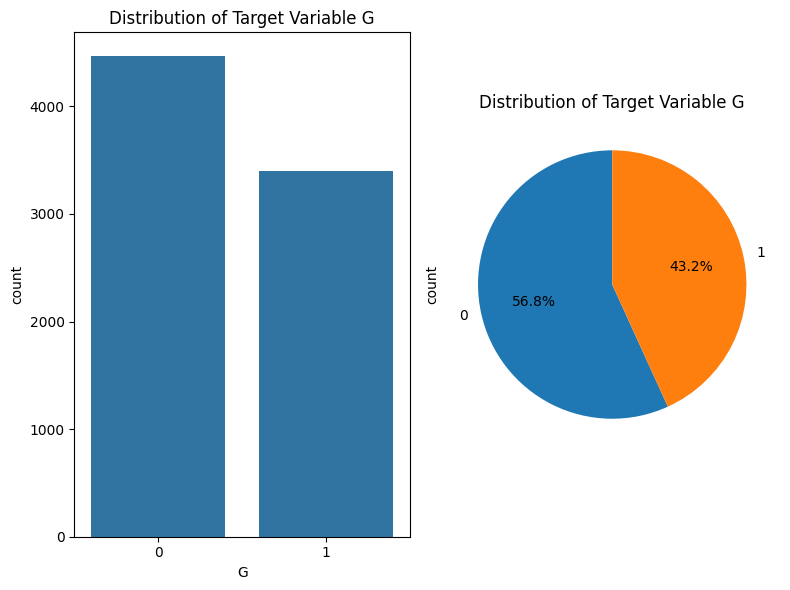

In [6]:
ax = plt.figure(figsize=(8, 6))
ax = plt.subplot(1, 2, 1)
ax = sns.countplot(x='G', data=df)
ax.set_title('Distribution of Target Variable G')

ax = plt.subplot(1, 2, 2)
ax = df.G.value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
ax.set_title('Distribution of Target Variable G')
plt.tight_layout()

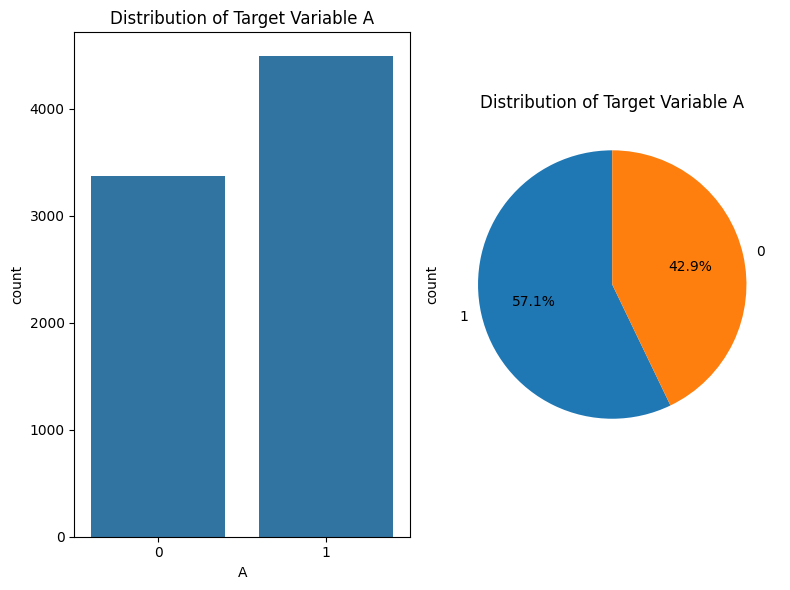

In [7]:
ax = plt.figure(figsize=(8, 6))
ax = plt.subplot(1, 2, 1)
ax = sns.countplot(x='A', data=df)
ax.set_title('Distribution of Target Variable A')

ax = plt.subplot(1, 2, 2)
ax = df.A.value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
ax.set_title('Distribution of Target Variable A')
plt.tight_layout()

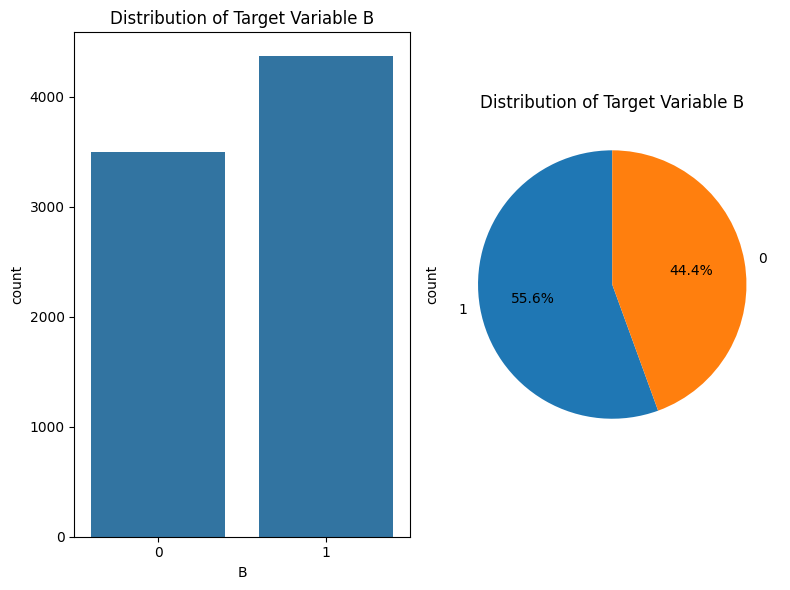

In [8]:
ax = plt.figure(figsize=(8, 6))
ax = plt.subplot(1, 2, 1)
ax = sns.countplot(x='B', data=df)
ax.set_title('Distribution of Target Variable B')

ax = plt.subplot(1, 2, 2)
ax = df.B.value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
ax.set_title('Distribution of Target Variable B')
plt.tight_layout()

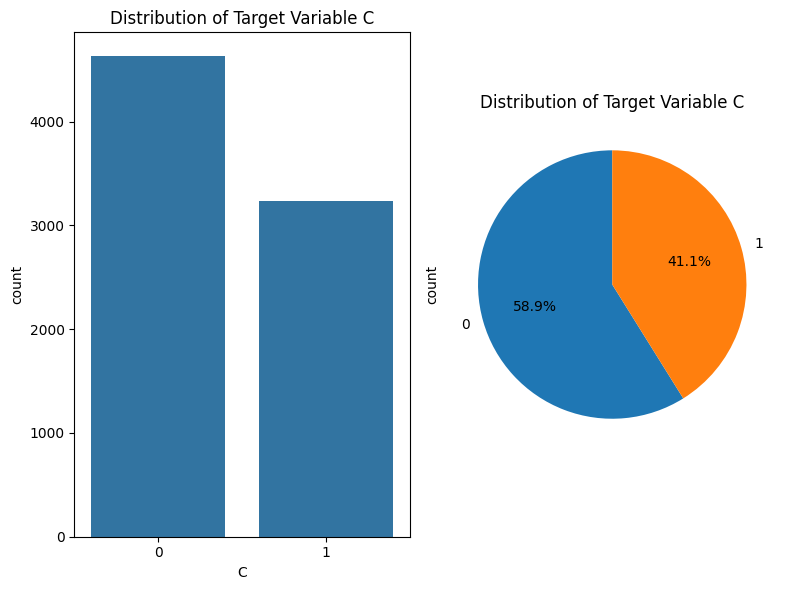

In [9]:
ax = plt.figure(figsize=(8, 6))
ax = plt.subplot(1, 2, 1)
ax = sns.countplot(x='C', data=df)
ax.set_title('Distribution of Target Variable C')

ax = plt.subplot(1, 2, 2)
ax = df.C.value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
ax.set_title('Distribution of Target Variable C')
plt.tight_layout()

In [10]:
df_copy = df.copy()
df_copy['Fault_Type'] = df_copy['G'].astype('str') + df_copy['C'].astype('str') + df_copy['B'].astype('str') + df_copy['A'].astype('str')
df_copy.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1001
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1001
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1001
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1001
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1001


In [11]:
df = df_copy.copy()

df['Fault_Type'][df['Fault_Type'] == '0000' ] = 'NO Fault'
df['Fault_Type'][df['Fault_Type'] == '1001' ] = 'Line A to Ground Fault'
df['Fault_Type'][df['Fault_Type'] == '0110' ] = 'Line B to Line C Fault'
df['Fault_Type'][df['Fault_Type'] == '1011' ] = 'Line A Line B to Ground Fault'
df['Fault_Type'][df['Fault_Type'] == '0111' ] = 'Line A Line B Line C'
df['Fault_Type'][df['Fault_Type'] == '1111' ] = 'Line A Line B Line C to Ground Fault'

df.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,Line A to Ground Fault
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,Line A to Ground Fault
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,Line A to Ground Fault
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,Line A to Ground Fault
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,Line A to Ground Fault


<Axes: ylabel='Fault_Type'>

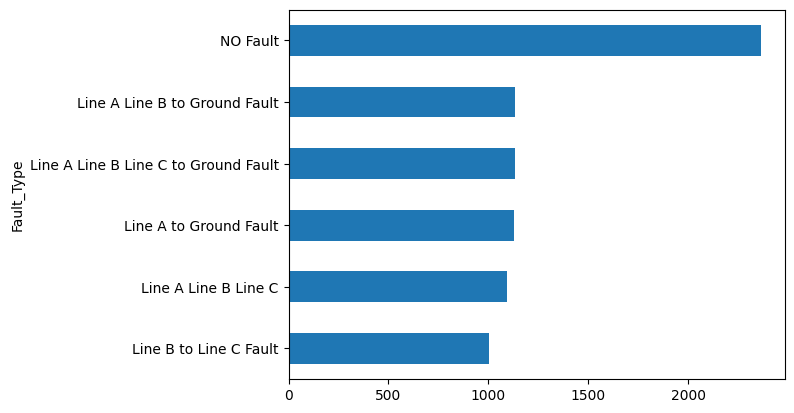

In [12]:
df['Fault_Type'].value_counts(ascending=True).plot.barh()

Visualizations

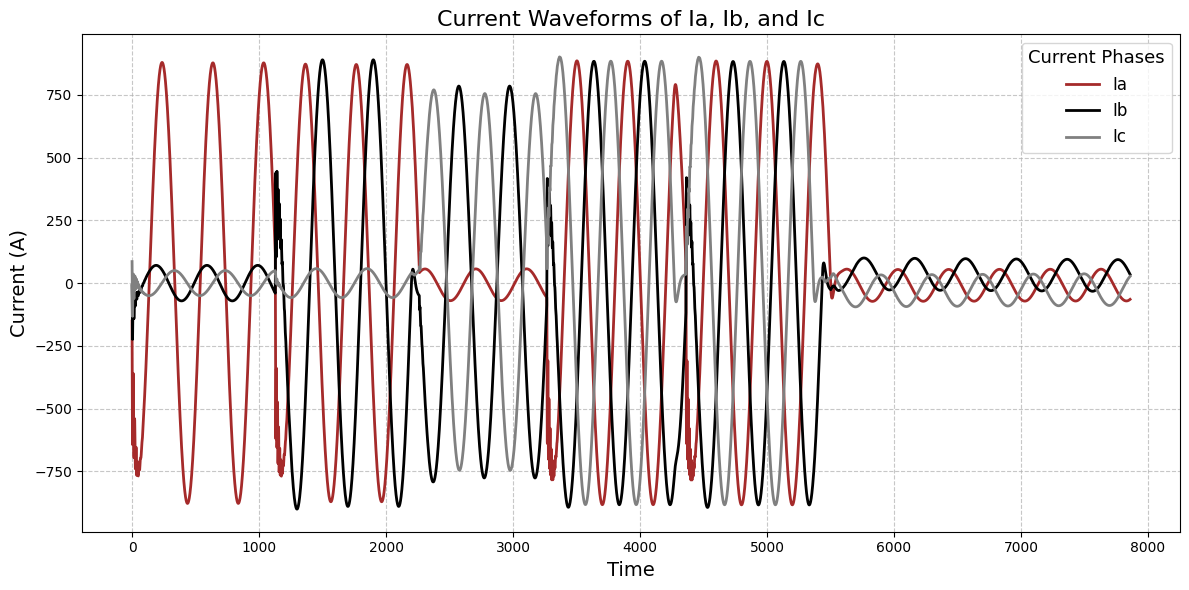

In [13]:
import matplotlib.pyplot as plt

# Set up the figure
plt.figure(figsize=(12, 6))

# Plot each current with specified colors
plt.plot(df['Ia'], label='Ia', color='brown',  linewidth=2)
plt.plot(df['Ib'], label='Ib', color='black',  linewidth=2)
plt.plot(df['Ic'], label='Ic', color='grey',  linewidth=2)

# Add labels and title
plt.xlabel('Time', fontsize=14)
plt.ylabel('Current (A)', fontsize=14)
plt.title('Current Waveforms of Ia, Ib, and Ic', fontsize=16)
plt.legend(title='Current Phases', title_fontsize='13', fontsize='12')
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

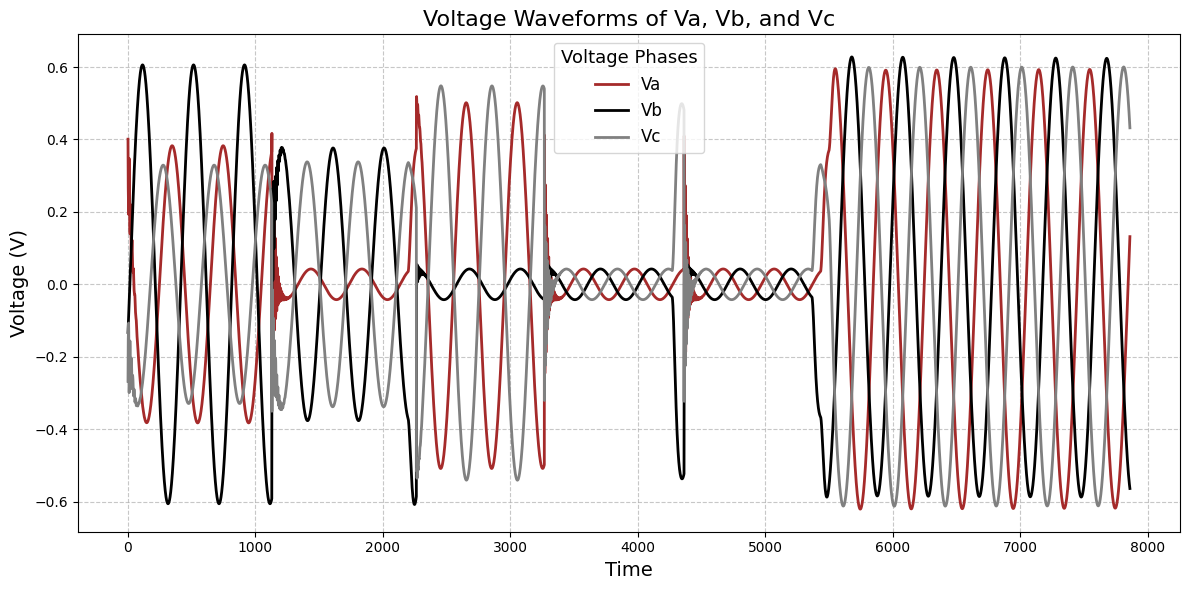

In [14]:
# Set up the figure
plt.figure(figsize=(12, 6))

# Plot each voltage with specified colors
plt.plot(df['Va'], label='Va', color='brown',  linewidth=2)  # Phase 1
plt.plot(df['Vb'], label='Vb', color='black',  linewidth=2)  # Phase 2
plt.plot(df['Vc'], label='Vc', color='grey',  linewidth=2)  # Phase 3

# Add labels and title
plt.xlabel('Time', fontsize=14)
plt.ylabel('Voltage (V)', fontsize=14)
plt.title('Voltage Waveforms of Va, Vb, and Vc', fontsize=16)
plt.legend(title='Voltage Phases', title_fontsize='13', fontsize='12')
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()


In [15]:
# No Fault
no_fault = df[df['Fault_Type'] == 'NO Fault']
no_fault.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
5496,0,0,0,0,61.806321,-22.861987,21.102428,0.366320,-0.567179,0.200859,NO Fault
5497,0,0,0,0,48.041678,-23.401108,21.273066,0.367341,-0.564257,0.196916,NO Fault
5498,0,0,0,0,34.256533,-23.909263,21.408047,0.368258,-0.561168,0.192910,NO Fault
5499,0,0,0,0,20.464350,-24.396165,21.501503,0.369086,-0.557916,0.188830,NO Fault
5500,0,0,0,0,7.109677,-25.075888,21.341967,0.370321,-0.554505,0.184184,NO Fault


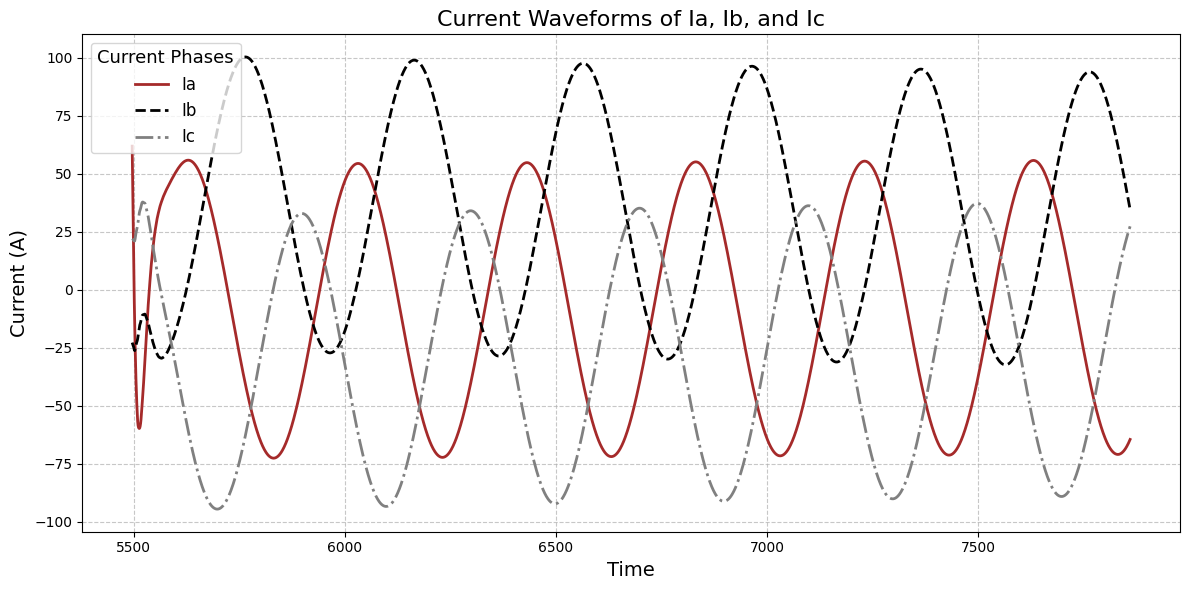

In [16]:
import matplotlib.pyplot as plt

# Set up the figure
plt.figure(figsize=(12, 6))

# Plot each current with specified colors
plt.plot(no_fault['Ia'], label='Ia', color='brown', linestyle='-', linewidth=2)
plt.plot(no_fault['Ib'], label='Ib', color='black', linestyle='--', linewidth=2)
plt.plot(no_fault['Ic'], label='Ic', color='grey', linestyle='-.', linewidth=2)

# Add labels and title
plt.xlabel('Time', fontsize=14)
plt.ylabel('Current (A)', fontsize=14)
plt.title('Current Waveforms of Ia, Ib, and Ic', fontsize=16)
plt.legend(title='Current Phases', title_fontsize='13', fontsize='12')
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

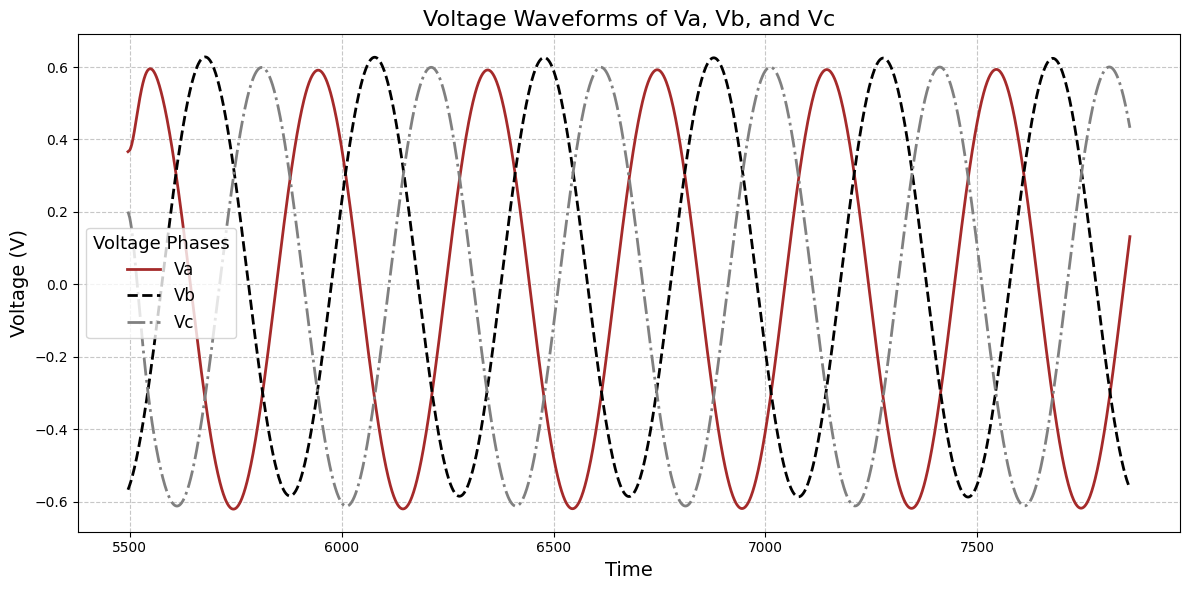

In [17]:
plt.figure(figsize=(12, 6))

# Plots each voltage 
plt.plot(no_fault['Va'], label='Va', color='brown', linestyle='-', linewidth=2)
plt.plot(no_fault['Vb'], label='Vb', color='black', linestyle='--', linewidth=2)
plt.plot(no_fault['Vc'], label='Vc', color='grey', linestyle='-.', linewidth=2)

# Add labels and title
plt.xlabel('Time', fontsize=14)
plt.ylabel('Voltage (V)', fontsize=14)
plt.title('Voltage Waveforms of Va, Vb, and Vc', fontsize=16)
plt.legend(title='Voltage Phases', title_fontsize='13', fontsize='12')
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

#### Fault visualizations

In [18]:
line_AG_Fault = df[df['Fault_Type'] == 'Line A to Ground Fault']
line_AG_Fault.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,Line A to Ground Fault
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,Line A to Ground Fault
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,Line A to Ground Fault
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,Line A to Ground Fault
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,Line A to Ground Fault


In [19]:
line_ABG_Fault = df[df['Fault_Type'] == 'Line A Line B to Ground Fault']
line_ABG_Fault.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
1129,1,0,1,1,-83.713374,42.102812,38.015631,0.416930,-0.066439,-0.350491,Line A Line B to Ground Fault
1130,1,0,1,1,-304.258650,243.536374,42.670680,0.097053,0.089765,-0.186818,Line A Line B to Ground Fault
1131,1,0,1,1,-487.104324,377.325956,29.573282,-0.132447,0.203226,-0.070779,Line A Line B to Ground Fault
1132,1,0,1,1,-603.543045,439.399623,9.638569,-0.248609,0.263483,-0.014873,Line A Line B to Ground Fault
1133,1,0,1,1,-620.718849,423.222790,0.613787,-0.226918,0.254651,-0.027733,Line A Line B to Ground Fault


In [20]:
def plot_waveforms(df):
    """
    Plots current and voltage waveforms for phases Ia, Ib, Ic, Va, Vb, and Vc using a given DataFrame.

    Parameters:
    - df: The DataFrame containing the current and voltage data.
           It is assumed that the DataFrame contains columns: 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc'.
           The index of the DataFrame will be used as the time axis.
    """

    # Plot current waveforms
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Ia'], label='Ia', color='brown', linestyle='-', linewidth=2)
    plt.plot(df.index, df['Ib'], label='Ib', color='black', linestyle='--', linewidth=2)
    plt.plot(df.index, df['Ic'], label='Ic', color='grey', linestyle='-.', linewidth=2)

    # Add labels and title for current
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Current (A)', fontsize=14)
    plt.title('Current Waveforms of Ia, Ib, and Ic', fontsize=16)
    plt.legend(title='Current Phases', title_fontsize='13', fontsize='12')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Display the current waveform plot
    plt.tight_layout()
    plt.show()

    # Plot voltage waveforms
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Va'], label='Va', color='brown', linestyle='-', linewidth=2)
    plt.plot(df.index, df['Vb'], label='Vb', color='black', linestyle='--', linewidth=2)
    plt.plot(df.index, df['Vc'], label='Vc', color='grey', linestyle='-.', linewidth=2)

    # Add labels and title for voltage
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Voltage (V)', fontsize=14)
    plt.title('Voltage Waveforms of Va, Vb, and Vc', fontsize=16)
    plt.legend(title='Voltage Phases', title_fontsize='13', fontsize='12')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Display the voltage waveform plot
    plt.tight_layout()
    plt.show()


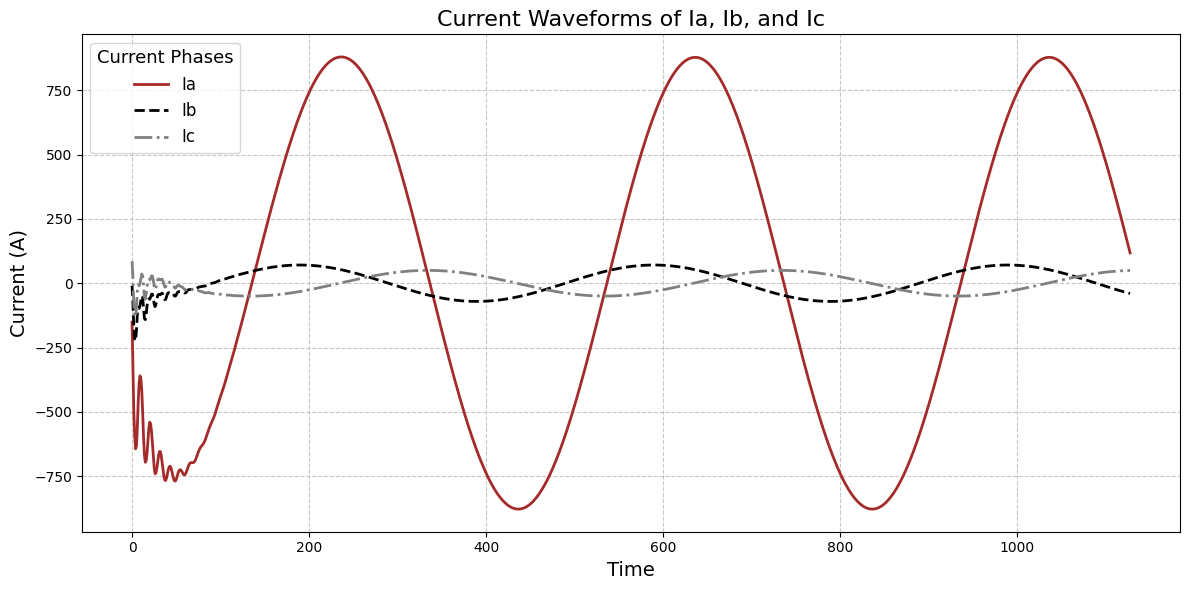

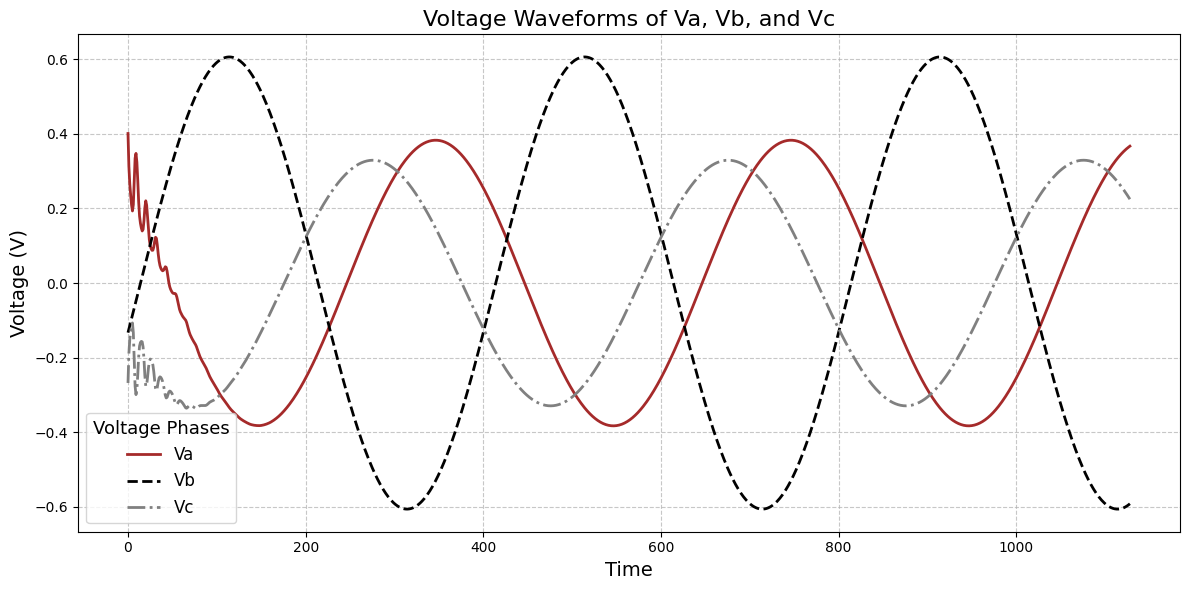

In [21]:
plot_waveforms(line_AG_Fault)

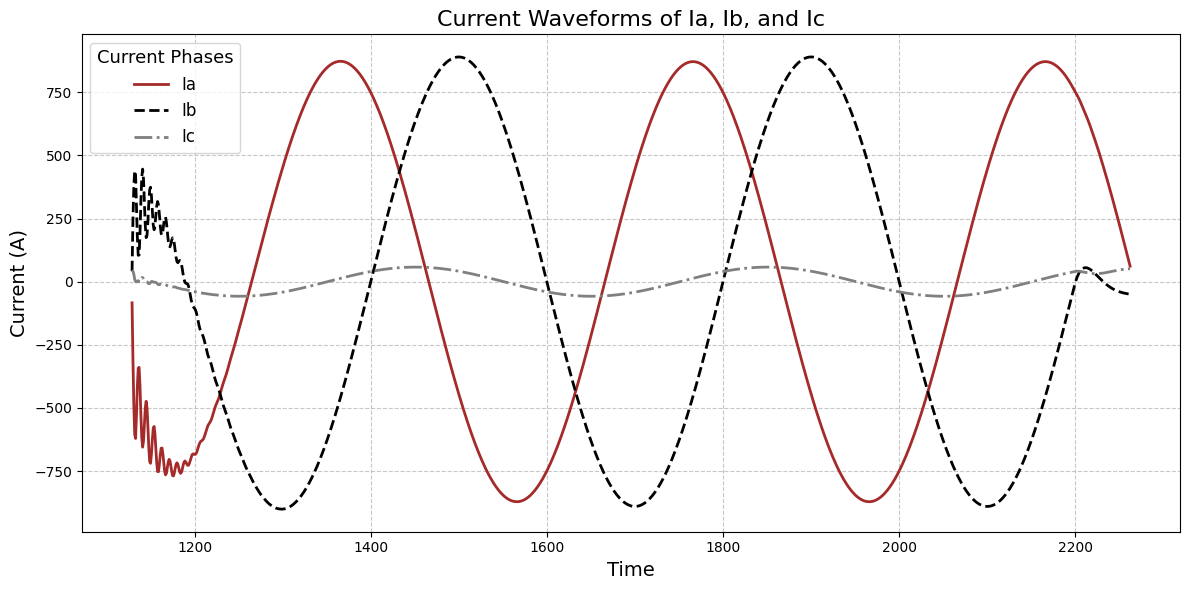

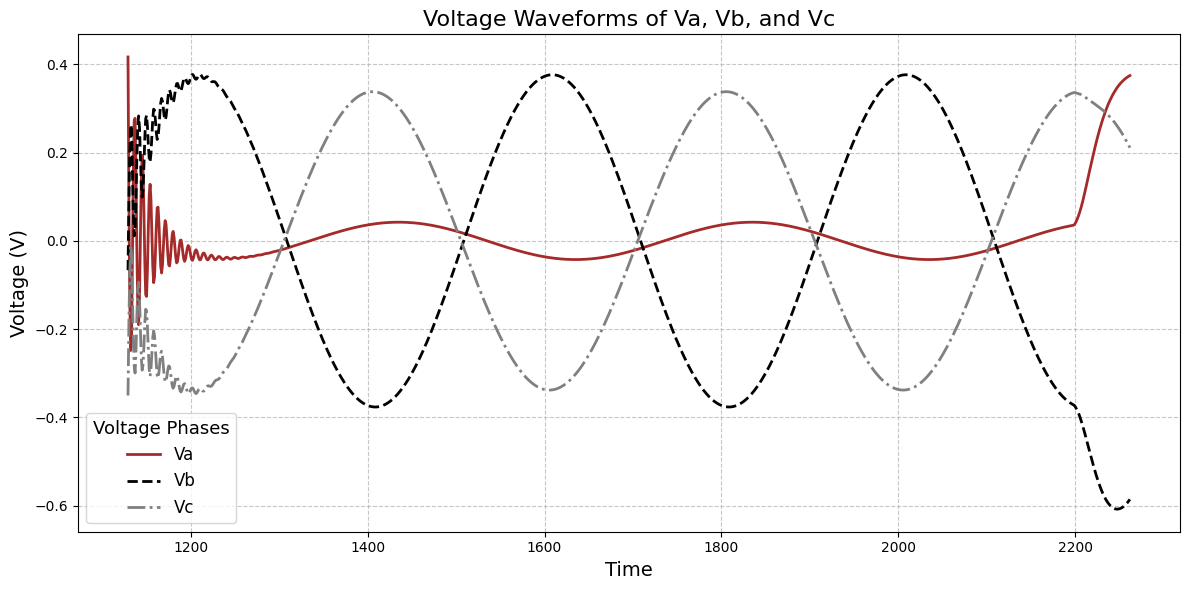

In [22]:
plot_waveforms(line_ABG_Fault)

In [23]:
line_BC_Fault = df[df['Fault_Type'] == 'Line B to Line C Fault']
line_BC_Fault.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
2263,0,1,1,0,41.764455,-93.940215,55.022192,0.517510,-0.003685,-0.513825,Line B to Line C Fault
2264,0,1,1,0,42.394348,-105.038998,65.494029,0.518491,-0.008071,-0.510420,Line B to Line C Fault
2265,0,1,1,0,43.010571,-105.734383,65.569977,0.511217,0.003798,-0.515015,Line B to Line C Fault
2266,0,1,1,0,43.612456,-100.121739,59.347319,0.499096,0.025105,-0.524201,Line B to Line C Fault
2267,0,1,1,0,44.202230,-95.078643,53.707382,0.487527,0.045052,-0.532579,Line B to Line C Fault


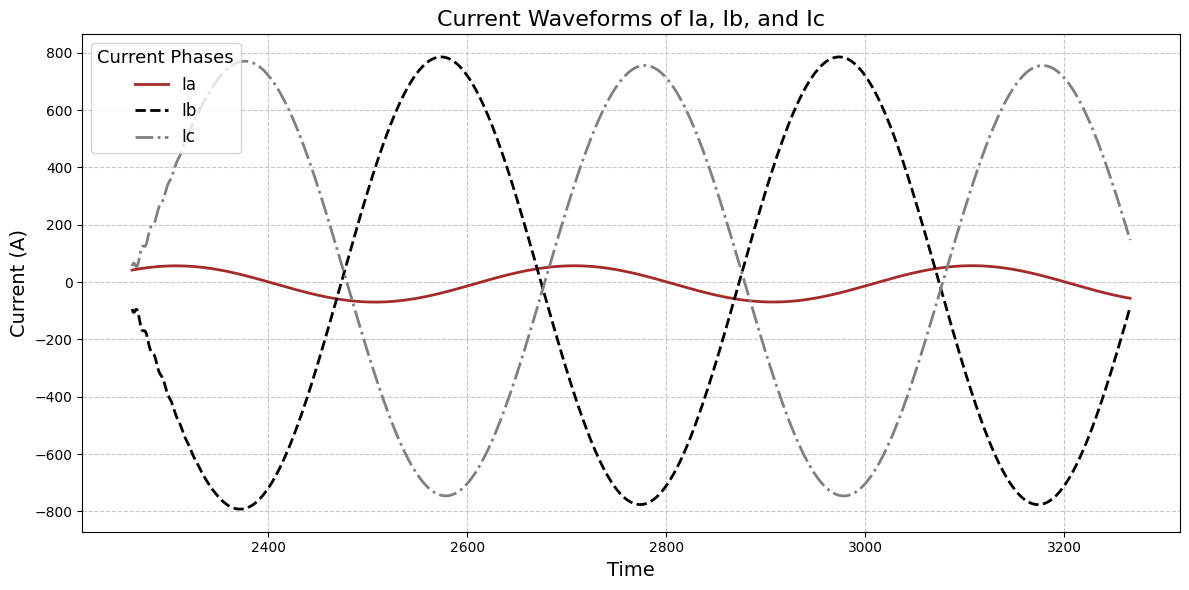

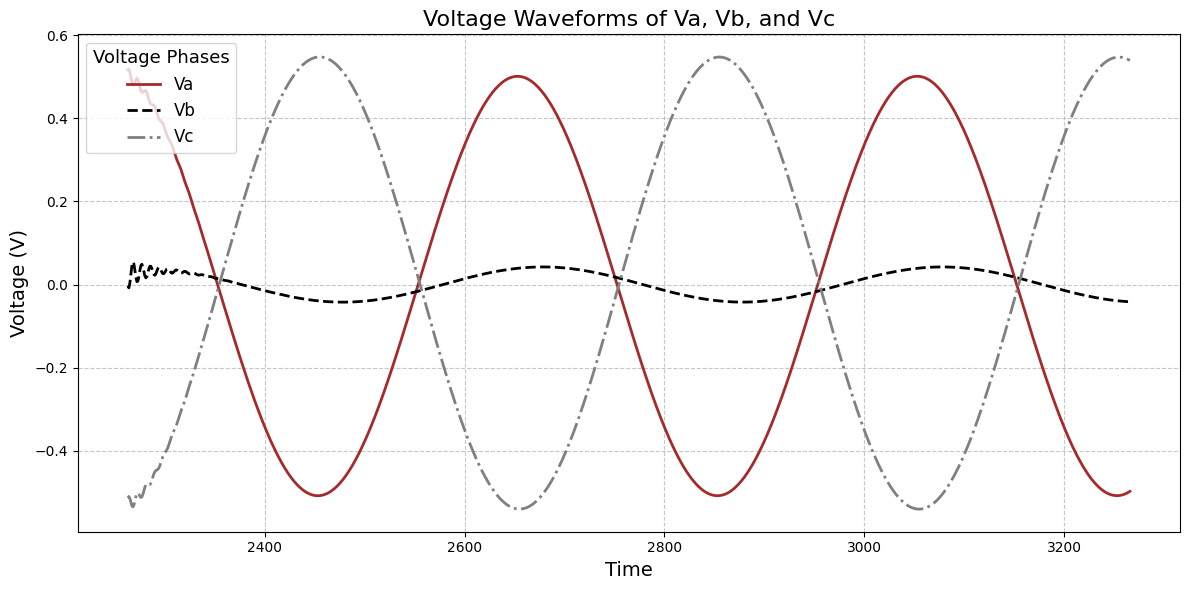

In [24]:
plot_waveforms(line_BC_Fault)

In [25]:
line_ABC_Fault = df[df['Fault_Type'] == 'Line A Line B Line C']
line_ABC_Fault.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
3267,0,1,1,1,-99.274309,44.146905,57.318650,0.412305,-0.091525,-0.320781,Line A Line B Line C
3268,0,1,1,1,-342.196277,218.566556,125.820753,0.095905,-0.003471,-0.092434,Line A Line B Line C
3269,0,1,1,1,-526.696029,347.197345,181.689494,-0.131094,0.056790,0.074304,Line A Line B Line C
3270,0,1,1,1,-633.453623,416.942091,218.702118,-0.245984,0.084683,0.161301,Line A Line B Line C
3271,0,1,1,1,-639.192926,412.122656,229.260639,-0.224523,0.075580,0.148943,Line A Line B Line C


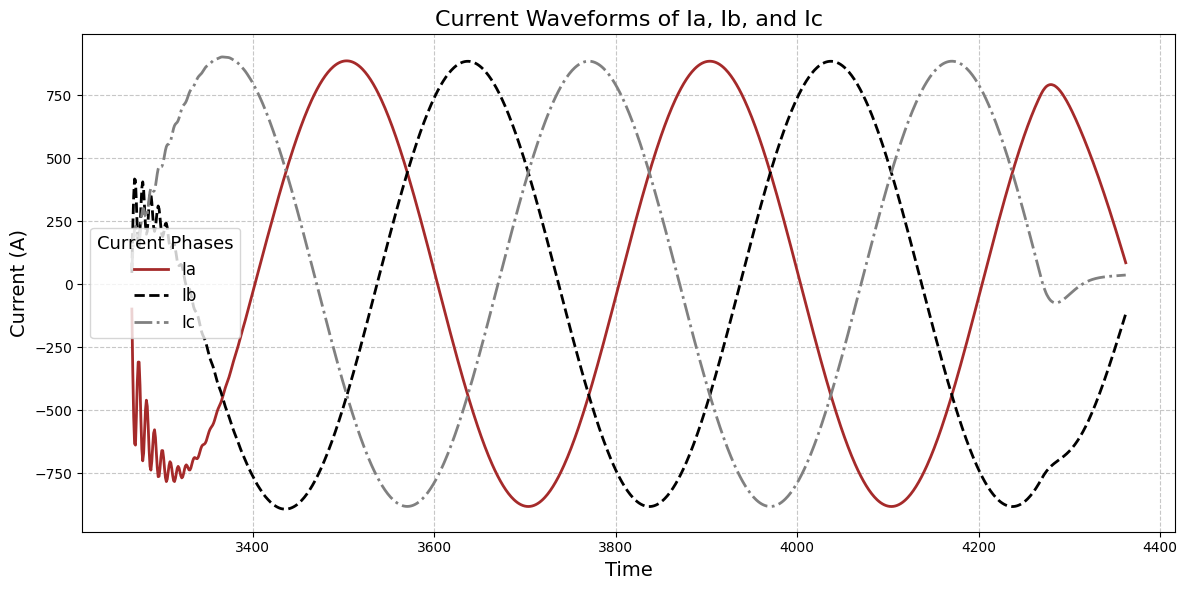

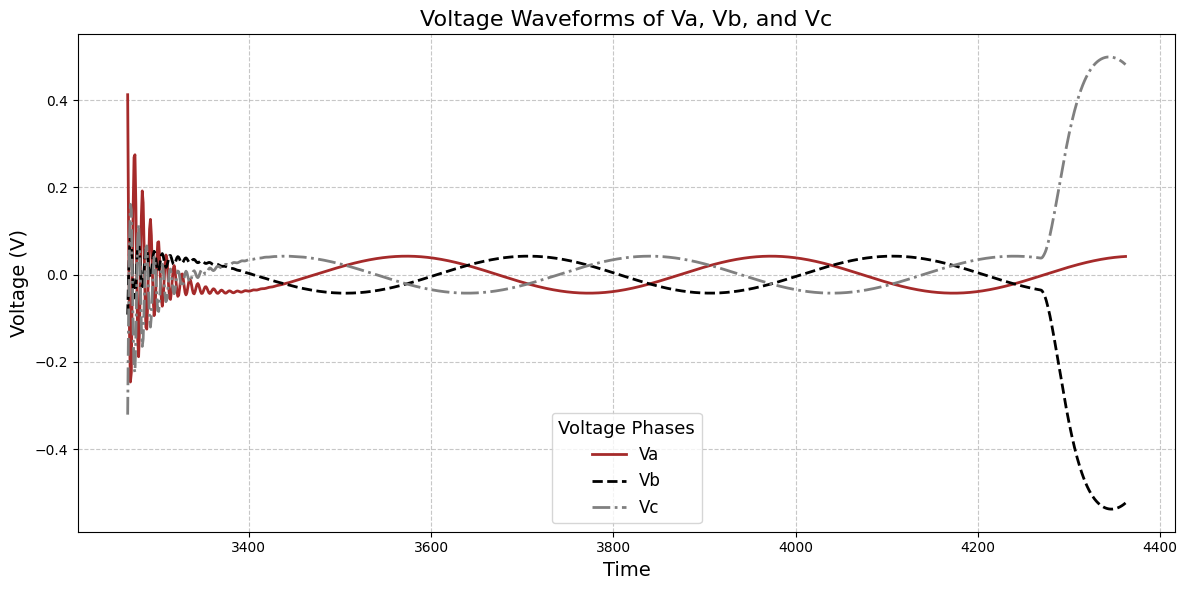

In [26]:
plot_waveforms(line_ABC_Fault)

In [27]:
line_ABCG_Fault = df[df['Fault_Type'] == 'Line A Line B Line C to Ground Fault']
line_ABCG_Fault.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
4363,1,1,1,1,-99.252463,52.717974,48.341534,0.410059,-0.086914,-0.323145,Line A Line B Line C to Ground Fault
4364,1,1,1,1,-342.238819,224.821345,119.149604,0.095347,-0.002326,-0.093021,Line A Line B Line C to Ground Fault
4365,1,1,1,1,-526.874012,351.614759,176.674369,-0.130437,0.055441,0.074996,Line A Line B Line C to Ground Fault
4366,1,1,1,1,-633.768916,420.246089,214.577137,-0.244709,0.082066,0.162643,Line A Line B Line C to Ground Fault
4367,1,1,1,1,-639.566896,415.329565,225.117414,-0.223359,0.073192,0.150167,Line A Line B Line C to Ground Fault


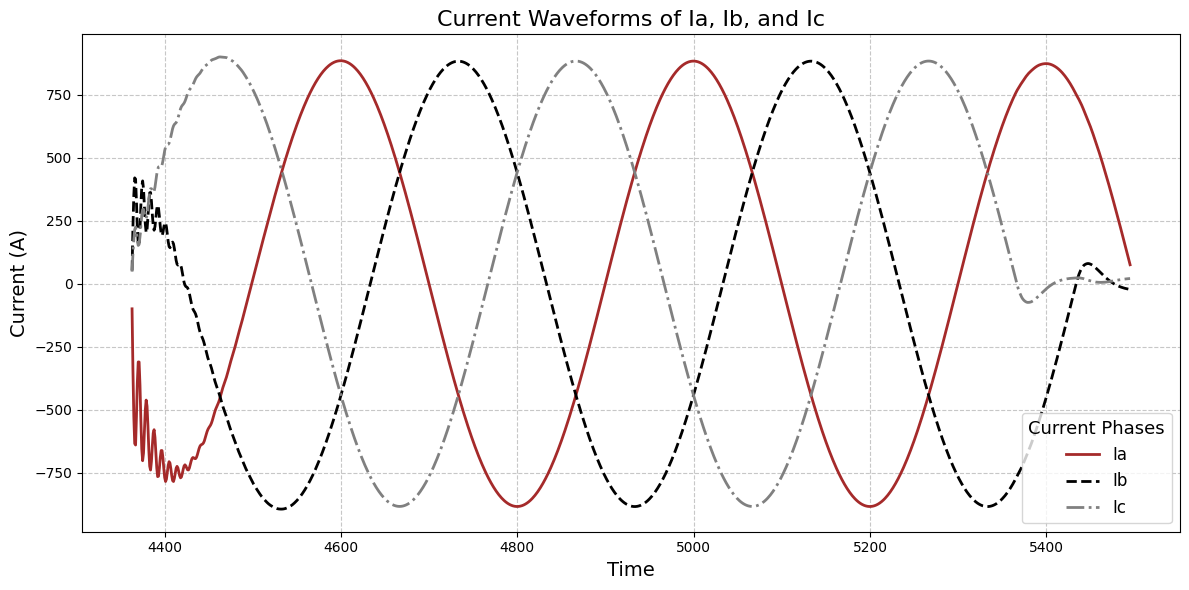

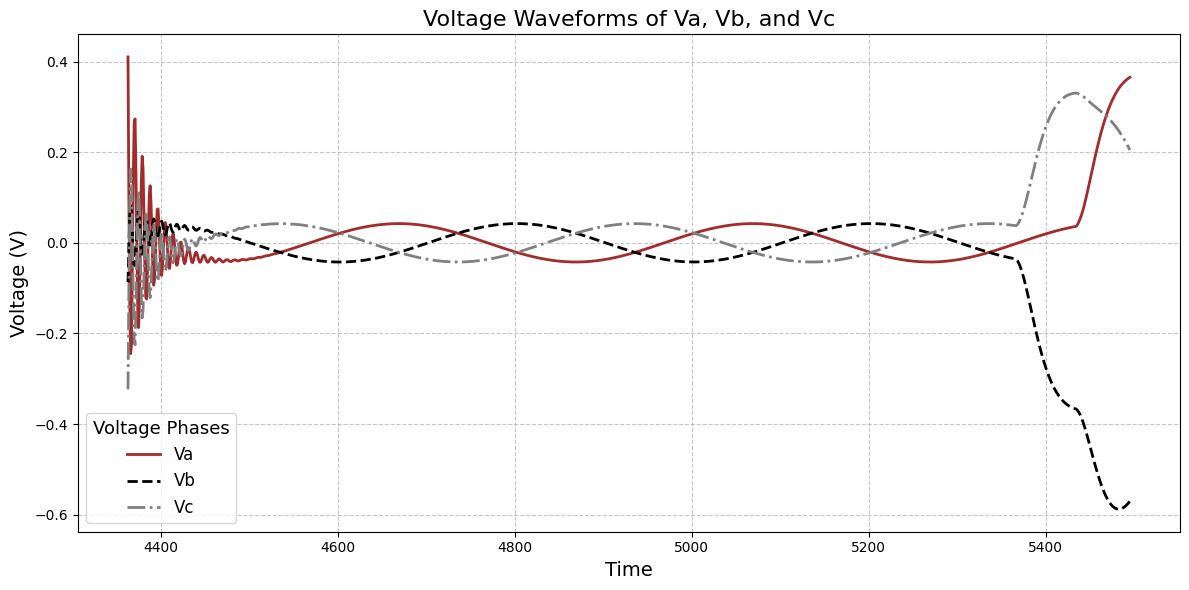

In [28]:
plot_waveforms(line_ABCG_Fault)

##### Features Engineering

In [29]:
df.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,Line A to Ground Fault
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,Line A to Ground Fault
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,Line A to Ground Fault
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,Line A to Ground Fault
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,Line A to Ground Fault


In [30]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Fault_Type'] = encoder.fit_transform(df['Fault_Type'])
df.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,3
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,3
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,3
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,3
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,3


In [31]:
df = df.drop(['G', 'C', 'B', 'A'], axis=1)
df.head()

,Ia,Ib,Ic,Va,Vb,Vc,Fault_Type
0,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,3
1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,3
2,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,3
3,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,3
4,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,3


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('Fault_Type', axis=1)
y = df['Fault_Type']

X_scaled = scaler.fit_transform(X)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [34]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

print(X_train.shape, y_train.shape)

torch.Size([6288, 6]) torch.Size([6288])


Model Training

In [35]:
from VAE import VAE, vae_loss

torch.manual_seed(42)

model = VAE(input_dim=X_train.shape[1], latent_dim=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.5)
# loss_fn = vae_loss()

In [36]:
def train(model:torch.nn.Module,
         X_train:torch.Tensor,
         y_train:torch.Tensor,
         Epochs:int=100):

    torch.manual_seed(42)

    for epoch in range(Epochs):
        #1. Forward pass
        model.train()
        recon_x, mu, logvar = model(X_train)

        #2. Compute loss
        loss = vae_loss(recon_x, X_train, mu, logvar)

        #3. Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{Epochs}], Loss: {loss.item():.4f}')

In [37]:
train(model, X_train, y_train, Epochs=100)

Epoch [10/100], Loss: 37875.7344
Epoch [20/100], Loss: 37911.2109
Epoch [30/100], Loss: 37909.9805
Epoch [40/100], Loss: 37866.0898
Epoch [50/100], Loss: 37878.3203
Epoch [60/100], Loss: 37904.7500
Epoch [70/100], Loss: 37895.7500
Epoch [80/100], Loss: 37886.9219
Epoch [90/100], Loss: 37891.3984
Epoch [100/100], Loss: 37887.0117


In [38]:
def evaluate_model(model:torch.nn.Module,
                    X_test:torch.Tensor):
    model.eval()
    with torch.inference_mode():
        recon_x, mu, logvar = model(X_test)
        loss = vae_loss(recon_x, X_test, mu, logvar)
        print(f'Test Loss: {loss.item():.4f}')

In [39]:
evaluate_model(model, X_test)

Test Loss: 9509.9639


In [40]:
test_df = pd.read_csv('detect_dataset.csv')
test_df.head()

,Output (S),Ia,Ib,Ic,Va,Vb,Vc,Unnamed: 7,Unnamed: 8
0,0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431,NaN,NaN
1,0,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202,NaN,NaN
2,0,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251,NaN,NaN
3,0,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963,NaN,NaN
4,0,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050,NaN,NaN


In [41]:
test_df = test_df.drop(['Output (S)'], axis=1)


In [42]:
test_df = test_df[['Ia','Ib','Ic','Va','Vb','Vc']]

test_df.head()
test_df_scaled = scaler.transform(test_df)
test_df = torch.tensor(test_df_scaled, dtype=torch.float32)
# test_df.head()

In [43]:
evaluate_model(model, test_df)

Test Loss: 72436.9688
